# Lagrangian Coherent Structure (LCS) Map Around the Cabo Verde Region

In [1]:
import math
from datetime import timedelta

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd

import parcels
from parcels import StatusCode

In [2]:
flowfield_env = xr.open_dataset("../data/ssc.nc")
flowfield_env

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 31, latitude: 85, longitude: 109)
Coordinates:
  * time       (time) datetime64[ns] 248B 2025-08-01 2025-08-02 ... 2025-08-31
  * latitude   (latitude) float32 340B 13.0 13.08 13.17 ... 19.83 19.92 20.0
  * longitude  (longitude) float32 436B -29.0 -28.92 -28.83 ... -20.08 -20.0
    depth      float32 4B ...
Data variables:
    uo         (time, latitude, longitude) float32 1MB ...
    vo         (time, latitude, longitude) float32 1MB ...
Attributes:
    Conventions:               CF-1.8
    area:                      Global
    contact:                   https://marine.copernicus.eu/contact
    credit:                    E.U. Copernicus Marine Service Information (CM...
    institution:               Mercator Ocean International
    licence:                   http://marine.copernicus.eu/services-portfolio...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    references:                http://marine.copernicus.eu
    source:                    MOI GLO12
    title:                     daily mean fields from Global Ocean Physics An...
    copernicusmarine_version:  2.4.1

## Boundary Conditions

In [3]:
flowfield_env["uo"][:, :,  0] = 0.0
flowfield_env["uo"][:, :, -1] = 0.0
flowfield_env["uo"][:,  0, :] = 0.0
flowfield_env["uo"][:, -1, :] = 0.0
flowfield_env["vo"][:, :,  0] = 0.0
flowfield_env["vo"][:, :, -1] = 0.0
flowfield_env["vo"][:,  0, :] = 0.0
flowfield_env["vo"][:, -1, :] = 0.0

In [4]:
ocean_mask = flowfield_env.uo.mean("time").notnull().astype(float)

In [5]:
v_repel = 0.02

mask = ocean_mask.values
nj, ni = mask.shape
u_rep_arr = np.zeros((nj, ni))
v_rep_arr = np.zeros((nj, ni))

for j in range(1, nj - 1):
    for i in range(1, ni - 1):
        if mask[j, i] == 0:
            continue
        if mask[j,   i-1] == 0: u_rep_arr[j, i] += v_repel
        if mask[j,   i+1] == 0: u_rep_arr[j, i] -= v_repel
        if mask[j-1, i  ] == 0: v_rep_arr[j, i] += v_repel
        if mask[j+1, i  ] == 0: v_rep_arr[j, i] -= v_repel

In [6]:
u_repel = xr.DataArray(u_rep_arr, coords=ocean_mask.coords, dims=ocean_mask.dims)
v_repel_field = xr.DataArray(v_rep_arr, coords=ocean_mask.coords, dims=ocean_mask.dims)

In [7]:
flowfield_env["uo"] = flowfield_env.uo + u_repel
flowfield_env["vo"] = flowfield_env.vo + v_repel_field

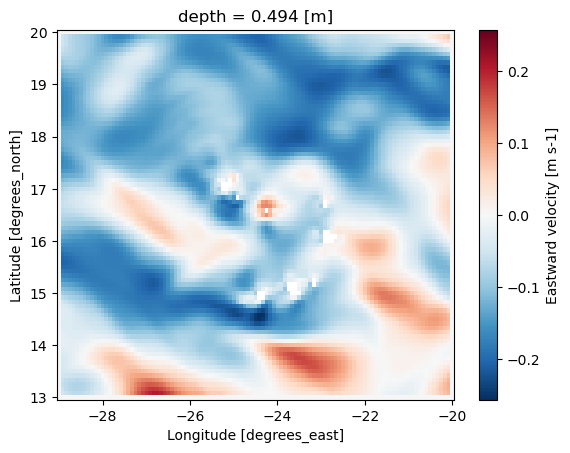

In [8]:
flowfield_env.uo.mean("time").plot()

## Parameters

In [9]:
lon_min = -29
lon_max = -22.5
lat_min = 14
lat_max = 19.5

delta_m, deg_lat_m = 2000.0, 111320.0

grid_points_lon = 200
grid_points_lat = 200

integration_days = 10

In [10]:
eigenvector_plot_count = grid_points_lon * grid_points_lat

## Parcels Fieldset

In [11]:
fieldset = parcels.FieldSet.from_xarray_dataset(
    flowfield_env,
    variables={"U": "uo", "V": "vo"},
    dimensions={"lon": "longitude", "lat": "latitude", "time": "time"},
)

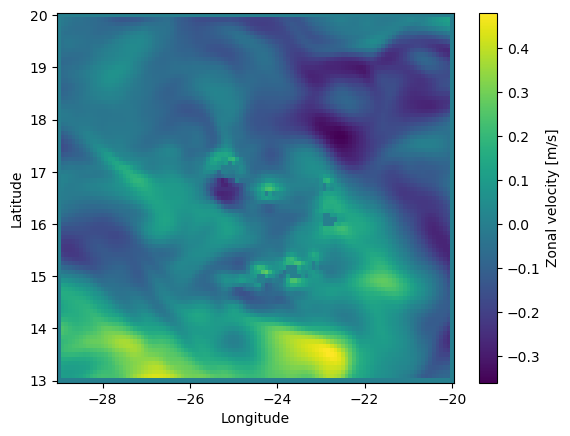

In [12]:
fieldset.computeTimeChunk()

plt.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[11, :, :])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="Zonal velocity [m/s]")
plt.show()

## Setting up Particle Triplets

In [13]:
lon_grid = np.linspace(lon_min, lon_max, grid_points_lon)
lat_grid = np.linspace(lat_min, lat_max, grid_points_lat)

In [14]:
lons = []
lats = []

for lon in lon_grid:
    for lat in lat_grid:

        lons.append(lon)
        lats.append(lat)

        lons.append(lon + (delta_m/(deg_lat_m * np.cos(np.radians(lat)))))
        lats.append(lat)

        lons.append(lon)
        lats.append(lat + (delta_m /deg_lat_m))

In [15]:
pset = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle,
    lon=lons,
    lat=lats,
    time=np.datetime64("2025-08-12"),
)
print(pset)

<ParticleSet>
    fieldset   :
        <FieldSet>
            fields:
                <Field>
                    name            : 'U'
                    grid            : RectilinearZGrid(lon=array([-29.00, -28.92, -28.83, ..., -20.17, -20.08, -20.00], shape=(109,), dtype=float32), lat=array([ 13.00,  13.08,  13.17, ...,  19.83,  19.92,  20.00], shape=(85,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  2419200.00,  2505600.00,  2592000.00], shape=(31,)), time_origin=2025-08-01T00:00:00.000000000, mesh='spherical')
                    extrapolate time: False
                    time_periodic   : False
                    gridindexingtype: 'nemo'
                    to_write        : False
                <Field>
                    name            : 'V'
                    grid            : RectilinearZGrid(lon=array([-29.00, -28.92, -28.83, ..., -20.17, -20.08, -20.00], shape=(109,), dtype=float32), lat=array([ 13.00,  13.08,  13.17, ...,  19.83,  19.92,  20.00], 

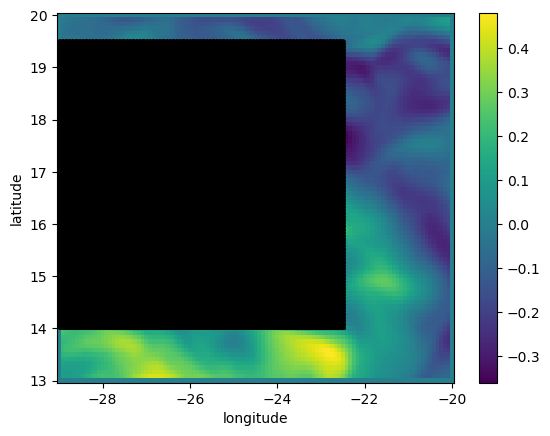

In [16]:
plt.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[11, :, :])
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.colorbar()

plt.plot(pset.lon, pset.lat, "ko", markersize=1)
plt.show()

## Particle Advection

In [17]:
output_file = pset.ParticleFile(
    name="../data/CV_gridParticles.zarr",
    outputdt=timedelta(hours=1), 
)

In [18]:
def CheckOutOfBounds(particle, fieldset, time):
    if particle.state == StatusCode.ErrorOutOfBounds:
        particle.delete()

def CheckError(particle, fieldset, time):
    if particle.state >= 50:
        particle.delete()

kernels = (
    pset.Kernel(parcels.AdvectionRK4)
    + pset.Kernel(CheckOutOfBounds)
)

pset.execute(
    kernels,
    runtime=timedelta(days=10),
    dt=timedelta(minutes=5),
    output_file=output_file,
)

INFO: Output files are stored in ../data/CV_gridParticles.zarr.
  0%|          | 0/864000.0 [00:00<?, ?it/s]

/home/b/b384140/.conda/envs/parcels/lib/python3.14/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/b/b384140/.conda/envs/parcels/lib/python3.14/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/b/b384140/.conda/envs/parcels/lib/python3.14/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


100%|██████████| 864000.0/864000.0 [03:53<00:00, 3707.51it/s]


In [19]:
print(pset)

<ParticleSet>
    fieldset   :
        <FieldSet>
            fields:
                <Field>
                    name            : 'U'
                    grid            : RectilinearZGrid(lon=array([-29.00, -28.92, -28.83, ..., -20.17, -20.08, -20.00], shape=(109,), dtype=float32), lat=array([ 13.00,  13.08,  13.17, ...,  19.83,  19.92,  20.00], shape=(85,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  2419200.00,  2505600.00,  2592000.00], shape=(31,)), time_origin=2025-08-01T00:00:00.000000000, mesh='spherical')
                    extrapolate time: False
                    time_periodic   : False
                    gridindexingtype: 'nemo'
                    to_write        : False
                <Field>
                    name            : 'V'
                    grid            : RectilinearZGrid(lon=array([-29.00, -28.92, -28.83, ..., -20.17, -20.08, -20.00], shape=(109,), dtype=float32), lat=array([ 13.00,  13.08,  13.17, ...,  19.83,  19.92,  20.00], 

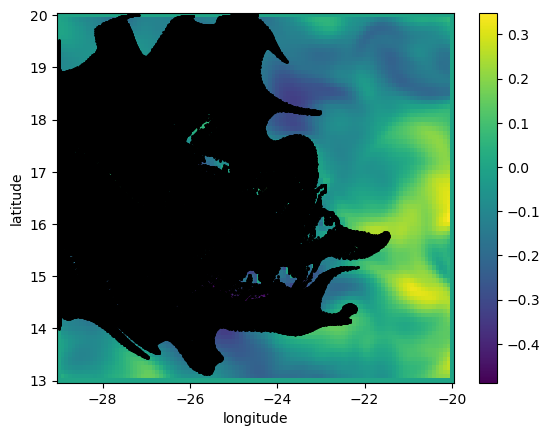

In [20]:
plt.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[21, :, :])
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.colorbar()

plt.plot(pset.lon, pset.lat, "ko", markersize = 1)
plt.show()

## Deformation Gradient Tensor

In [21]:
final_lon = pset.lon
final_lat = pset.lat

In [22]:
center = []
xshift = []
yshift = []

for i in range(0, len(final_lon) - len(final_lon) % 3, 3):
    center.append([final_lon[i], final_lat[i]])
    xshift.append([final_lon[i+1], final_lat[i+1]])
    yshift.append([final_lon[i+2], final_lat[i+2]])

center = np.array(center)
xshift = np.array(xshift)
yshift = np.array(yshift)

In [23]:
dXdx = (xshift[:, 0] - center[:, 0]) * deg_lat_m * np.cos(np.radians(center[:, 1])) / delta_m
dYdx = (xshift[:, 1] - center[:, 1]) * deg_lat_m / delta_m
dXdy = (yshift[:, 0] - center[:, 0]) * deg_lat_m * np.cos(np.radians(center[:, 1])) / delta_m
dYdy = (yshift[:, 1] - center[:, 1]) * deg_lat_m / delta_m

In [24]:
F = np.array([
    [dXdx, dXdy],
    [dYdx, dYdy],
])

## Cauchy-Green Strain Tensor computation

In [25]:
C   = np.einsum("kil,kjl->ijl", F, F) 
C_T = np.transpose(C, (2, 0, 1))      
eigenvalues, eigenvectors = np.linalg.eigh(C_T)

In [26]:
ev_max = eigenvectors[:, :, -1]

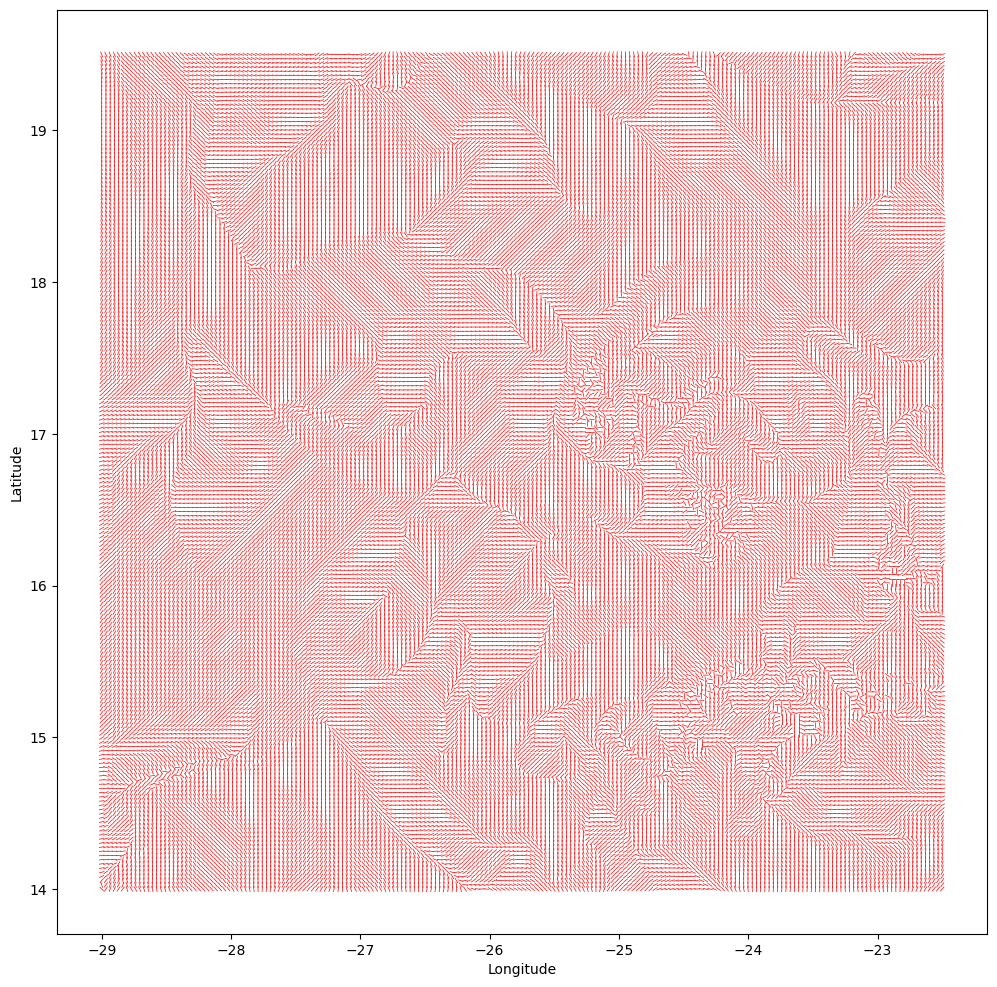

In [27]:
# eigenvector directions
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

for n in range(min(eigenvector_plot_count, len(ev_max))):
    _x = [lons[n*3] + (delta_m / (deg_lat_m * np.cos(np.radians(lats[n*3])))) * ev_max[n, 0],
          lons[n*3] - (delta_m / (deg_lat_m * np.cos(np.radians(lats[n*3])))) * ev_max[n, 0]]
    _y = [lats[n*3] + (delta_m / deg_lat_m) * ev_max[n, 1],
          lats[n*3] - (delta_m / deg_lat_m) * ev_max[n, 1]]
    ax.plot(_x, _y, 'r-', linewidth=0.5, alpha=1)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## LCS maps

In [28]:
T = integration_days * 24 * 60 * 60

In [29]:
max_eigenvalues = np.max(eigenvalues, axis=1)

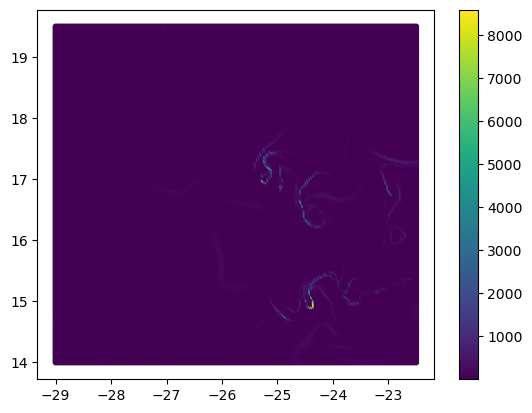

In [30]:
n = len(max_eigenvalues)
plt.scatter(lons[0::3][:n], lats[0::3][:n], 10, c=max_eigenvalues)
plt.colorbar()

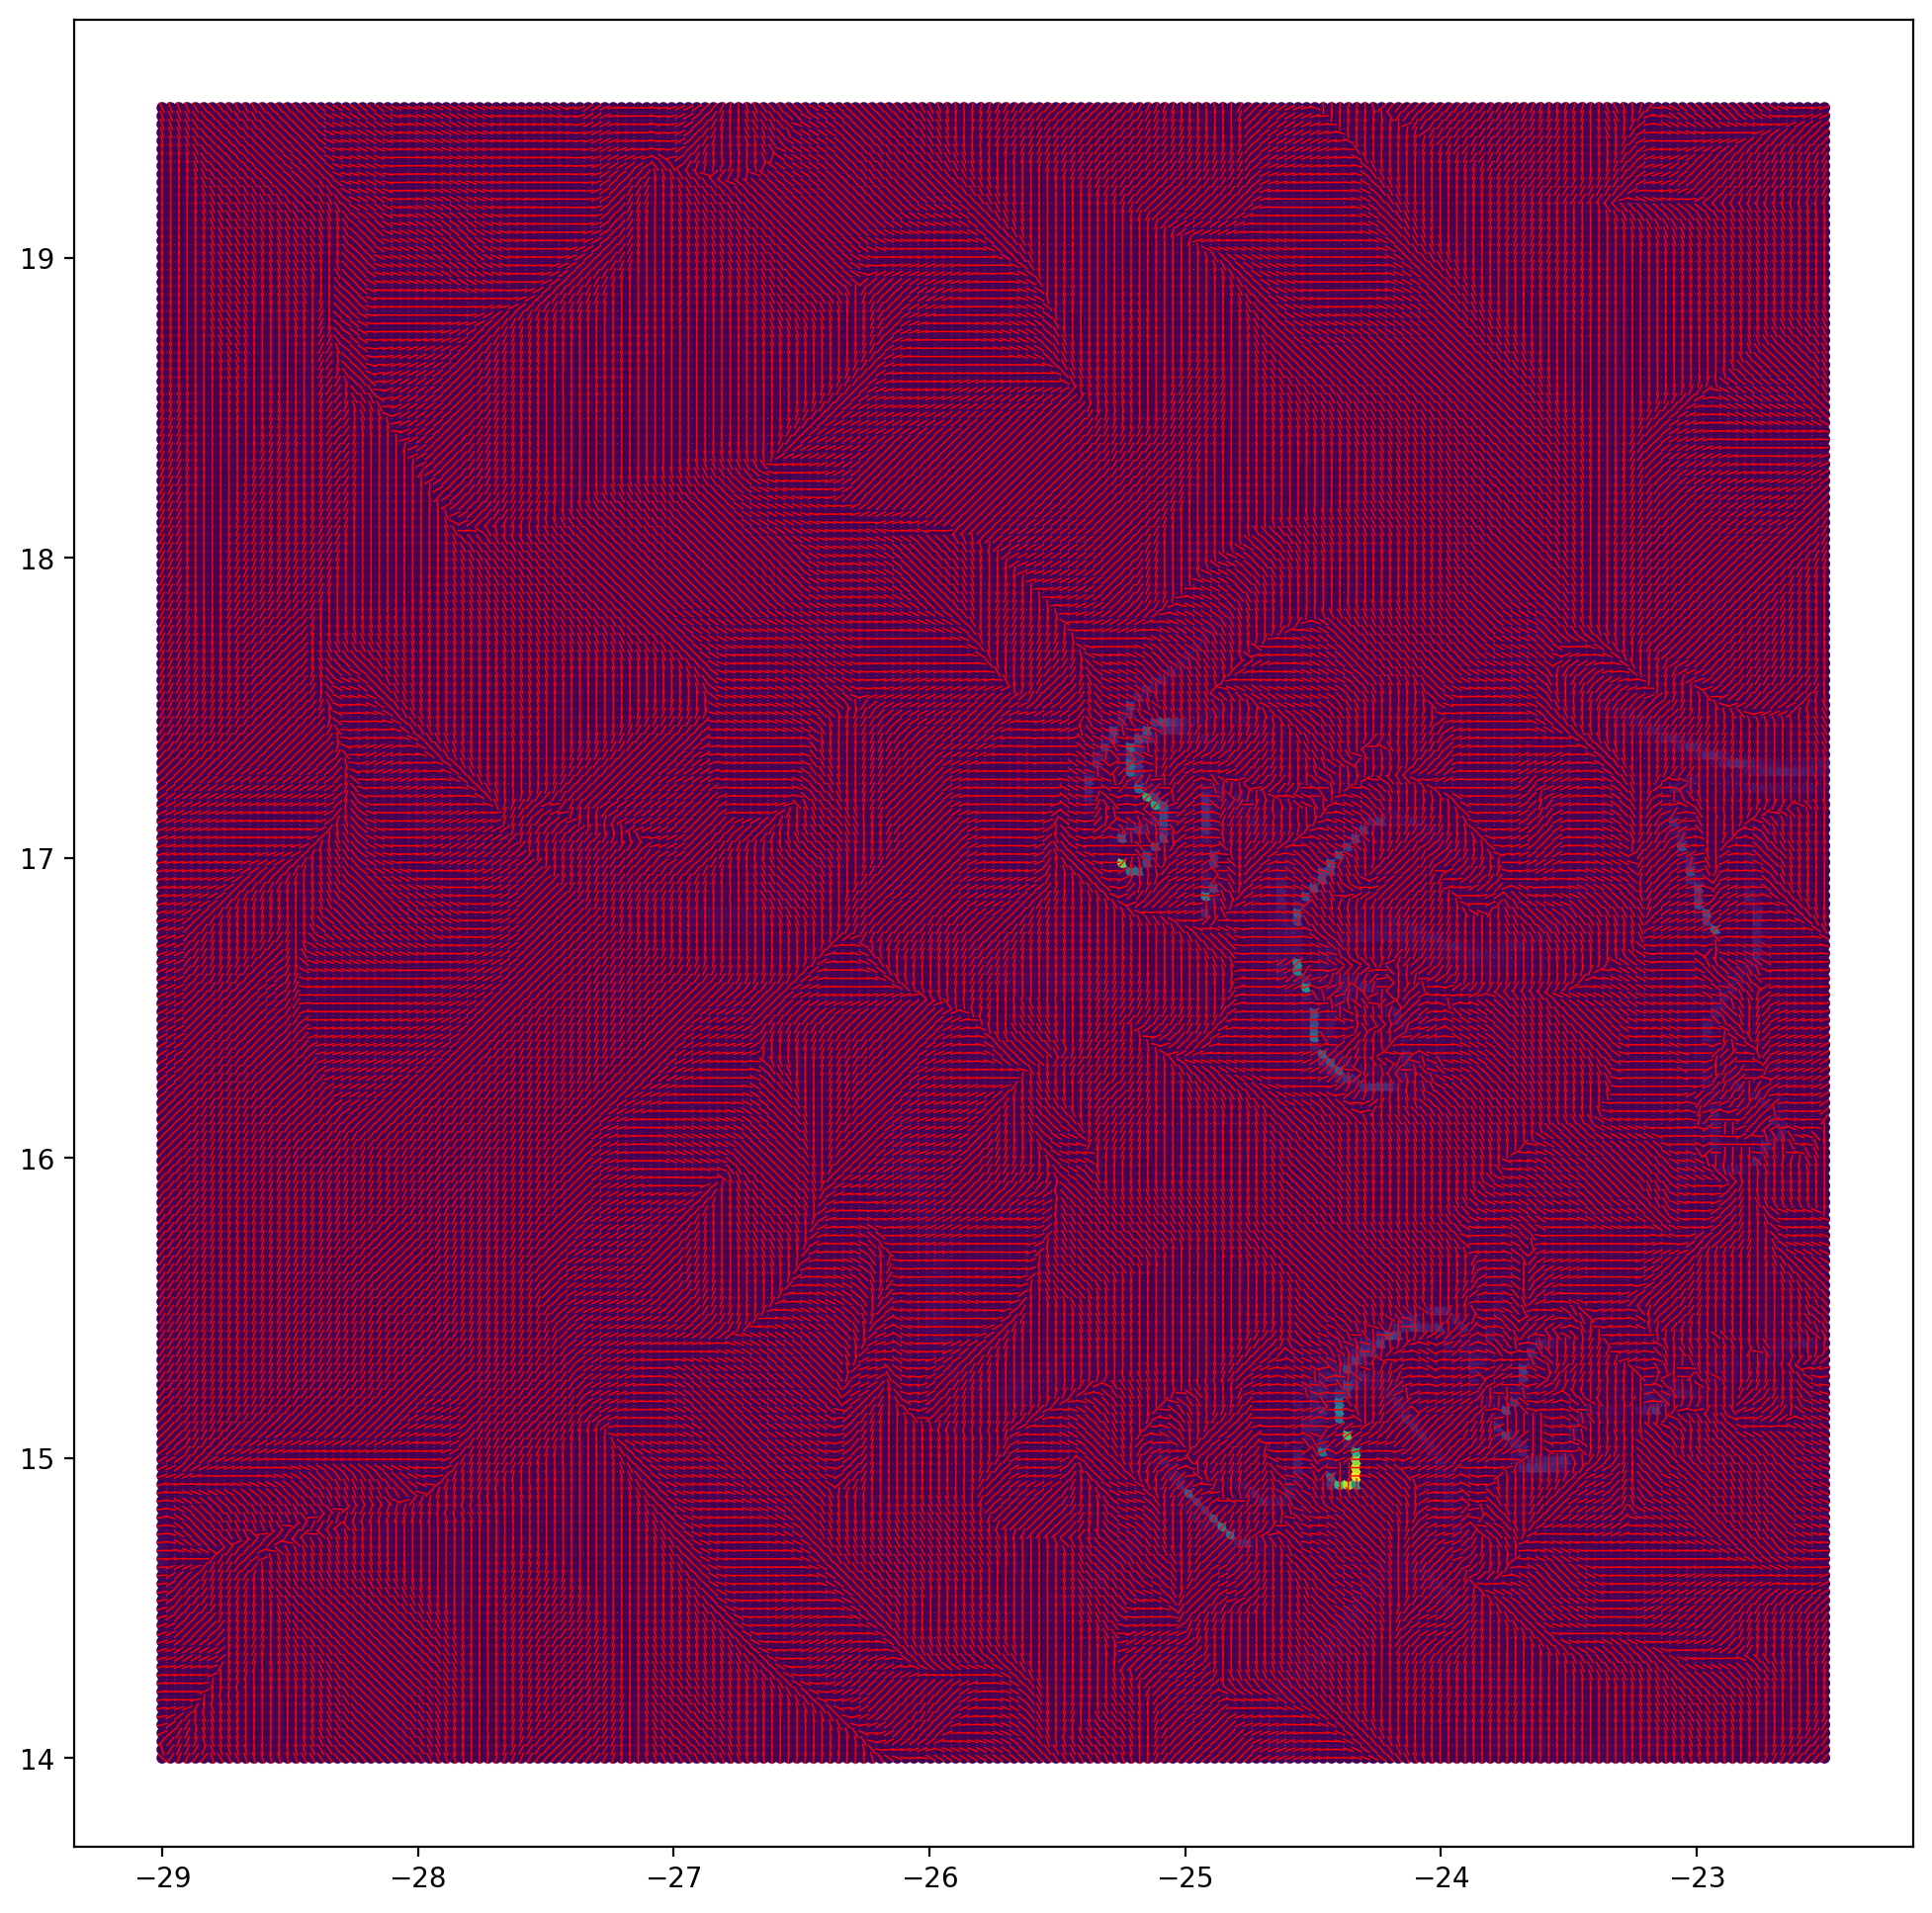

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

ax.scatter(lons[0::3], lats[0::3], 10, max_eigenvalues)

for n in range(min(eigenvector_plot_count, len(ev_max))):
    _x = [lons[n*3] + (delta_m / (deg_lat_m * np.cos(np.radians(lats[n*3])))) * ev_max[n, 0],
          lons[n*3] - (delta_m / (deg_lat_m * np.cos(np.radians(lats[n*3])))) * ev_max[n, 0]]
    _y = [lats[n*3] + (delta_m / deg_lat_m) * ev_max[n, 1],
          lats[n*3] - (delta_m / deg_lat_m) * ev_max[n, 1]]
    ax.plot(_x, _y, 'r-', linewidth=0.5, alpha=1)

fig.set_dpi(200)
plt.show()

In [32]:
FTLE = (1/(2*T)) * np.log(np.maximum(max_eigenvalues, 1e-10))

In [33]:
#FTLE_da = xr.DataArray(FTLE, 
#                      dims = ("pos",),
#                      coords = {"lon":(("pos",), lons[0::3]),
#                                "lat":(("pos",), lats[0::3])},
#                       name = "FTLE"
#                      )

In [34]:
#FTLE_da

In [35]:
#FTLE_da.to_dataset().to_netcdf("010_FTLE.nc")

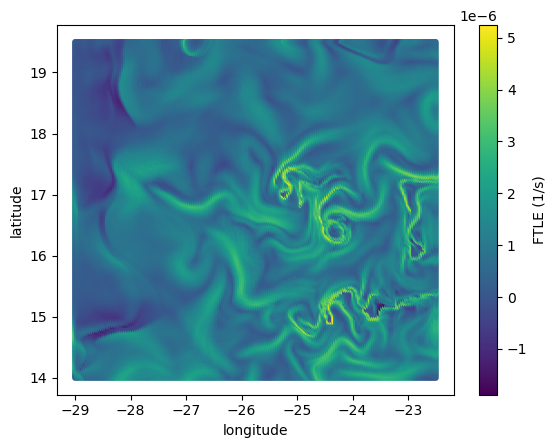

In [36]:
plt.scatter(lons[0::3], lats[0::3], 10, FTLE)
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.colorbar(label = "FTLE (1/s)")

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
sc = ax.scatter(lons[0::3], lats[0::3], 10, FTLE)
for n in range(min(eigenvector_plot_count, len(ev_max))):
    _x = [lons[n*3] + (delta_m / (deg_lat_m * np.cos(np.radians(lats[n*3])))) * ev_max[n, 0],
          lons[n*3] - (delta_m / (deg_lat_m * np.cos(np.radians(lats[n*3])))) * ev_max[n, 0]]
    _y = [lats[n*3] + (delta_m / deg_lat_m) * ev_max[n, 1],
          lats[n*3] - (delta_m / deg_lat_m) * ev_max[n, 1]]
    ax.plot(_x, _y, 'r-', linewidth=0.5, alpha=1)
fig.set_dpi(200)
plt.colorbar(sc, ax=ax, label="FTLE (1/s)")
plt.xlabel("longitude", size = 12)
plt.ylabel("latitude")
plt.savefig("ftle_overlay_cabo_verde.png", dpi=150)